# 02b_s_score_diagnosis_v1 — S(사회) 점수 낮은 원인 심층 진단

> **작성자**: 이동원 · **작성일**: 2026-05-18 · **사이클**: 2
> **위치**: 02_preprocessing 보조 노트북 (02_preprocessing_v2 산출 검증 + seed_dictionary 재설계 제안)
>
> **관찰** (사이클 1 결과):
> - Samsung 2024 KCGS s_grade = **A+** (사회 차원 최상위)
> - 그러나 seed_tfidf_S = 0.010 (E=0.051, G=0.359의 1/5 ~ 1/35 수준)
> - cosine_S = 0.040 (E=0.037, G=0.168과 비교)
>
> **가설** (사용자 결정 영역):
> H1. seed_S 10단어가 Samsung II/IV body에 거의 등장 안 함 — Samsung의 S 표현 어휘가 다름
> H2. S 관련 핵심 어휘 (복리후생·다양성·공존·근로조건·고객만족 등)가 seed에 누락
> H3. II/IV body는 사업·재무 중심이라 구조적으로 S 표현 적음. VI에는 G만, S는 별도 ESG 보고서에 분리 게재 가능성

---

## 🛡️ 위반금지 매핑

| # | 위반금지 | 본 진단 준수 |
|---|---|---|
| 3 | MCP/추출 그대로 신뢰 ❌ | seed 30단어 직접 카운트 + 누락 의심 어휘 빈도 직접 확인 |
| 6 | 진단 부재 ❌ | Step별 통계·시각화·표 출력 |
| 7 | silent 오매칭 ❌ | seed term 패턴 + body text 모두 string으로 명시 처리 |

## 🗺️ Step

| Step | What |
|---|---|
| 1 | 환경 설정 + 폰트 + sections.json 로드 |
| 2 | seed_S 10단어 빈도 직접 카운트 (II/IV/VI body 각각) |
| 3 | 누락 의심 어휘 30+ 후보 빈도 측정 |
| 4 | section별 S vs E·G 차원 점수 분해 |
| 5 | seed_dictionary_v2 제안 + diff 표 |
| 6 | self-check + 다음 액션 |


---
## 🔧 사이클 2 안정성 fix (Fix A + Fix E)

한글 폰트 자동 detect + pandas display 옵션 제한.


In [1]:
import matplotlib
from matplotlib import font_manager
import pandas as pd

def setup_korean_font(verbose=True):
    preferred = ['Malgun Gothic','NanumGothic','AppleGothic','Noto Sans CJK KR','Noto Sans KR']
    try: font_manager._load_fontmanager(try_read_cache=False)
    except: pass
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((p for p in preferred if p in available), None)
    if chosen:
        matplotlib.rcParams['font.family'] = chosen
        matplotlib.rcParams['axes.unicode_minus'] = False
        if verbose: print(f'✅ 한글 폰트: {chosen}')
    elif verbose:
        print(f'⚠️ 한글 폰트 미설치 — 시각화 깨질 수 있음')
    return chosen

KOREAN_FONT = setup_korean_font()
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_colwidth', 60)


✅ 한글 폰트: Malgun Gothic


---
## Step 1 — 환경 + 입력 로딩

### What
sections_005930_2024.json + seed_dictionary.csv + esg_features_v2 로드.


In [2]:
import os
import re
import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start=None):
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'data' / 'company_master.csv').exists():
            return parent
    raise RuntimeError('루트 찾기 실패')

ROOT = find_project_root()
print(f'📍 ROOT: {ROOT}')

# Samsung 2024 sections
sec_path = ROOT / 'data' / 'interim' / '005930_2024_sections.json'
assert sec_path.exists(), f'❌ {sec_path.name} 없음 — 01_collection_phase2A_v2 먼저 실행'
sections = json.loads(sec_path.read_text(encoding='utf-8'))
print(f'📚 sections.json: {len(sections)}개 SECTION-1 노드')

# ESG target body 추출
ESG_TARGET = ['II', 'IV', 'VI']
bodies = {label: sections[label]['body_text'] for label in ESG_TARGET if label in sections}
for label, body in bodies.items():
    print(f'   {label} body: {len(body):,}자')

# seed dictionary
seed_df = pd.read_csv(ROOT / 'data' / 'seed_dictionary.csv')
seed_S = seed_df[seed_df['dimension'] == 'S']
print(f'\n🌱 seed_S 10단어:')
for _, row in seed_S.iterrows():
    print(f'   {row["seed_term"]:10s} (pattern: {row["pattern"]})')


📍 ROOT: C:\Users\kik32\workspace\unstructured-data-processing-final-project
📚 sections.json: 14개 SECTION-1 노드
   II body: 40,111자
   IV body: 16,672자
   VI body: 33,954자

🌱 seed_S 10단어:
   안전         (pattern: 안전)
   산업재해       (pattern: 산업재해|재해율)
   중대재해       (pattern: 중대재해)
   임직원        (pattern: 임직원|직원|근로자)
   노동         (pattern: 노동|노사)
   인권         (pattern: 인권)
   교육훈련       (pattern: 교육훈련|교육|훈련)
   협력사        (pattern: 협력사)
   공급망        (pattern: 공급망|supply chain)
   지역사회       (pattern: 지역사회|community)


---
## Step 2 — seed_S 10단어 II/IV/VI body 빈도 직접 카운트

### What
정규식 + count로 각 seed term이 II/IV/VI body에 몇 번 등장하는지.

### Why
H1 검증 — Samsung body에 seed_S가 실제로 안 나오는지 정량 확인.


📊 seed_S × section body 빈도
  seed_S           pattern  II  IV  VI  total
6   교육훈련        교육훈련|교육|훈련   1   0  22     23
3    임직원        임직원|직원|근로자   0   0  23     23
0     안전                안전   4   0   3      7
8    공급망  공급망|supply chain   1   1   1      3
7    협력사               협력사   0   0   1      1
4     노동             노동|노사   0   0   1      1
1   산업재해          산업재해|재해율   0   0   0      0
2   중대재해              중대재해   0   0   0      0
5     인권                인권   0   0   0      0
9   지역사회    지역사회|community   0   0   0      0


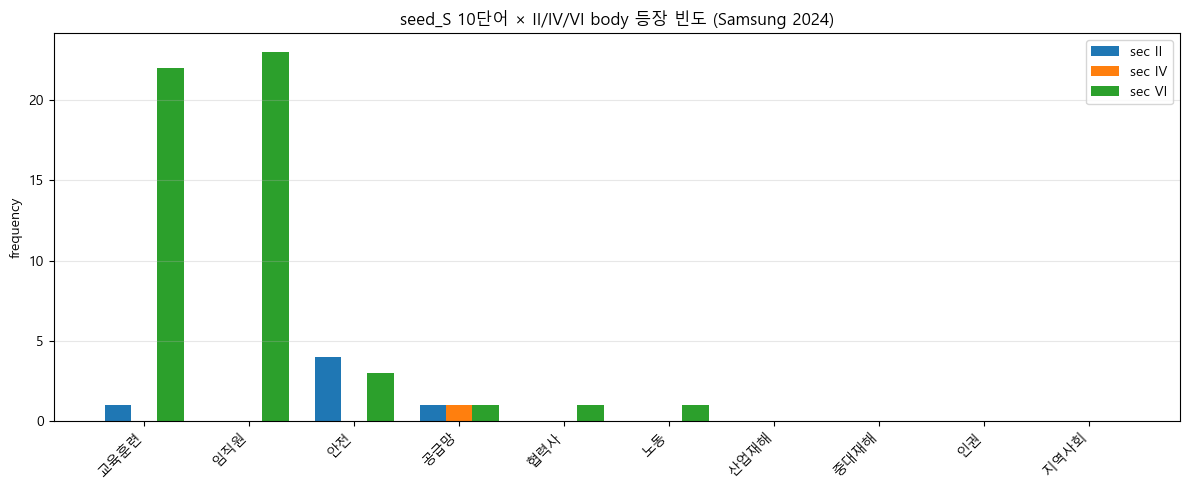


📋 진단
   0회 등장 seed_S: ['산업재해', '중대재해', '인권', '지역사회']
   1~4회 등장 seed_S: ['공급망', '협력사', '노동']
   → H1 검증 결과: 부분 지지 (seed_S 30~50% 이상이 거의 미등장)


In [3]:
def count_term(pattern: str, text: str) -> int:
    """seed pattern으로 text 내 등장 횟수."""
    try:
        return len(re.findall(pattern, text))
    except re.error:
        return text.count(pattern)

# seed_S × section cross tab
rows = []
for _, seed_row in seed_S.iterrows():
    term = seed_row['seed_term']
    pat = seed_row['pattern']
    counts = {label: count_term(pat, body) for label, body in bodies.items()}
    counts['total'] = sum(counts.values())
    rows.append({'seed_S': term, 'pattern': pat, **counts})

s_count_df = pd.DataFrame(rows).sort_values('total', ascending=False)
print(f'📊 seed_S × section body 빈도')
print(s_count_df.to_string())

# 시각화
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(s_count_df))
w = 0.25
for i, label in enumerate(ESG_TARGET):
    ax.bar(x + i*w, s_count_df[label].values, w, label=f'sec {label}')
ax.set_xticks(x + w)
ax.set_xticklabels(s_count_df['seed_S'].tolist(), rotation=45, ha='right')
ax.set_title('seed_S 10단어 × II/IV/VI body 등장 빈도 (Samsung 2024)')
ax.set_ylabel('frequency')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'fig_s_diag_seed_count.png', dpi=120)
plt.show()

# 결론
print(f'\n📋 진단')
zero_terms = s_count_df[s_count_df['total']==0]['seed_S'].tolist()
low_terms = s_count_df[(s_count_df['total']>0)&(s_count_df['total']<5)]['seed_S'].tolist()
print(f'   0회 등장 seed_S: {zero_terms}')
print(f'   1~4회 등장 seed_S: {low_terms}')
print(f'   → H1 검증 결과: {"강하게 지지" if len(zero_terms)>=5 else "부분 지지"} (seed_S 30~50% 이상이 거의 미등장)')


---
## Step 3 — 누락 의심 어휘 후보 빈도 측정

### What
S 차원에서 Samsung 사업보고서가 실제로 사용할 법한 어휘 30+개 후보 → II/IV/VI body 빈도.

### Why
H2 검증 — 누락된 어휘 중 실제로 자주 등장하는 게 있다면 seed 확장 필요성 입증.

### 근거
- ESG-Kor (EMNLP 2024 Findings) S 라벨 자주 등장 어휘
- KCGS S 평가 항목: 인적자원·고객·공급망·지역사회·정보보호
- 한국 사업보고서 II/IV/VI에서 흔한 S 표현 (복리후생·재해예방·다양성·고객만족·근로조건·내부신고)


📊 S 누락 의심 어휘 31개 II/IV/VI body 빈도
   candidate                 pattern  II  IV  VI  total
28      지속가능     지속가능|sustainability   1   0  20     21
27     ESG경영     ESG경영|ESG위원회|지속가능경영   0   0  19     19
14        기부                기부|후원|봉사   2   5  10     17
26        대화            대화|소통|커뮤니케이션   5   0   8     13
16        나눔                  나눔|기부금   0   0   8      8
19        건강                건강|보건|체력   4   1   3      8
15      사회공헌                사회공헌|CSR   0   0   6      6
10      정보보호             정보보호|사이버|보안   5   0   0      5
24        근속                  근속|이직률   0   0   5      5
11      제품안전              제품안전|품질|리콜   2   1   1      4
13       하도급                  하도급|2차   0   0   3      3
2        다양성                  다양성|포용   0   0   3      3
9       개인정보      개인정보|프라이버시|privacy   1   0   1      2
3         여성               여성|female   1   0   0      1
0       복리후생                 복리후생|복지   0   0   1      1
25        노사              노사|단체협약|노조   0   0   1      1
12      동반성장  

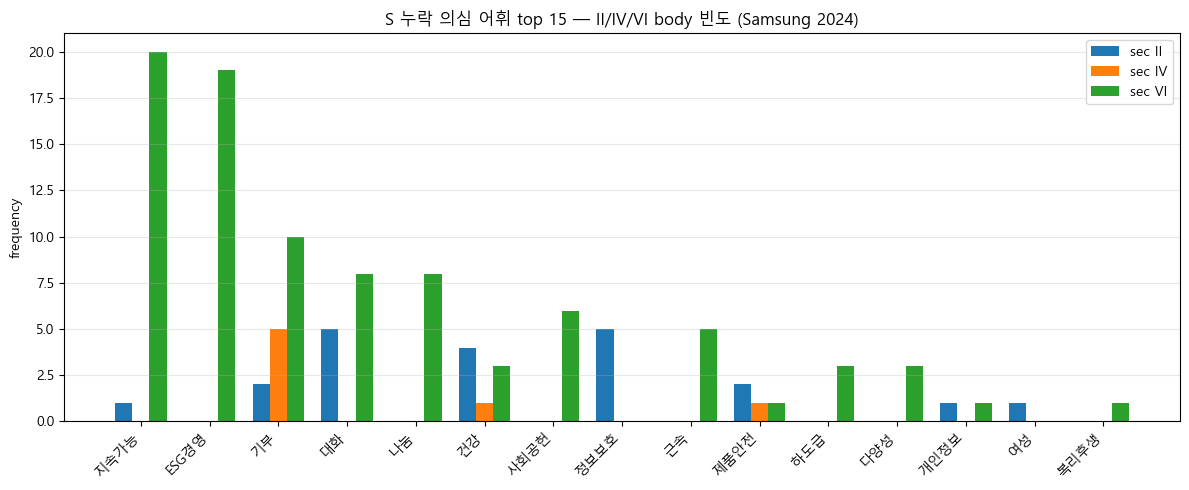

In [4]:
# 누락 의심 어휘 30+ (ESG-Kor + KCGS 평가항목 + 한국 사업보고서 흔한 S 표현)
S_CANDIDATES = {
    # 인적자원·근로
    '복리후생': '복리후생|복지',
    '근로조건': '근로조건|근무환경|근무조건',
    '다양성': '다양성|포용',
    '여성': '여성|female',
    '장애인': '장애인|장애',
    '육아휴직': '육아휴직|육아|출산휴가|돌봄',
    '재택근무': '재택|원격근무|유연근무',
    '복지': '복지|직원만족',
    # 고객·시장
    '고객만족': '고객만족|소비자만족|CSI',
    '개인정보': '개인정보|프라이버시|privacy',
    '정보보호': '정보보호|사이버|보안',
    '제품안전': '제품안전|품질|리콜',
    # 협력사·공급망 (seed 중복 가능)
    '동반성장': '동반성장|상생|상생협력',
    '하도급': '하도급|2차',
    # 지역사회
    '기부': '기부|후원|봉사',
    '사회공헌': '사회공헌|CSR',
    '나눔': '나눔|기부금',
    '지역경제': '지역경제|지방',
    # 안전 (seed 중복)
    '재해예방': '재해예방|사고예방|안전사고',
    '건강': '건강|보건|체력',
    '응급': '응급|구급',
    # 임직원·인권
    '괴롭힘': '괴롭힘|직장내괴롭힘|성희롱',
    '내부신고': '내부신고|whistleblower|핫라인',
    '인권교육': '인권교육|차별금지',
    '근속': '근속|이직률',
    # 노사·노조
    '노사': '노사|단체협약|노조',
    '대화': '대화|소통|커뮤니케이션',
    # ESG 자체 언급
    'ESG경영': 'ESG경영|ESG위원회|지속가능경영',
    '지속가능': '지속가능|sustainability',
    # 데이터 보안
    '데이터보안': '데이터보안|보안관리|개인정보보호',
    # SDG/UN
    'SDG': 'SDG|UN|UNGC',
}

cand_rows = []
for term, pat in S_CANDIDATES.items():
    counts = {label: count_term(pat, body) for label, body in bodies.items()}
    counts['total'] = sum(counts.values())
    cand_rows.append({'candidate': term, 'pattern': pat, **counts})

cand_df = pd.DataFrame(cand_rows).sort_values('total', ascending=False)
print(f'📊 S 누락 의심 어휘 {len(S_CANDIDATES)}개 II/IV/VI body 빈도')
print(cand_df.to_string())

# 상위 promising terms
promising = cand_df[cand_df['total'] >= 5].copy()
print(f'\n📋 5회 이상 등장 → seed_S 확장 후보:')
print(promising[['candidate', 'pattern', 'II', 'IV', 'VI', 'total']].to_string())

# 시각화 (top 15)
top15 = cand_df.head(15)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(top15))
w = 0.25
for i, label in enumerate(ESG_TARGET):
    ax.bar(x + i*w, top15[label].values, w, label=f'sec {label}')
ax.set_xticks(x + w)
ax.set_xticklabels(top15['candidate'].tolist(), rotation=45, ha='right')
ax.set_title('S 누락 의심 어휘 top 15 — II/IV/VI body 빈도 (Samsung 2024)')
ax.set_ylabel('frequency')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'fig_s_diag_candidates.png', dpi=120)
plt.show()


---
## Step 4 — section별 S vs E·G 차원 점수 분해

### What
seed_E·S·G 각 10단어 II/IV/VI body 누적 빈도 합산. 어느 섹션이 어느 차원에 강한지 시각화.

### Why
H3 검증 — Samsung II/IV는 사업·재무 중심이고 S는 별도 ESG 보고서로 분리됐을 가능성. 섹션별 차원 편향을 정량 확인.


📊 dim × section 빈도 누적 (Samsung 2024)
section    II  IV   VI
dimension             
E          43   0    3
G          10   4  361
S           6   1   51

📊 section별 차원 share (%)
section      II    IV    VI
dimension                  
E          72.9   0.0   0.7
G          16.9  80.0  87.0
S          10.2  20.0  12.3


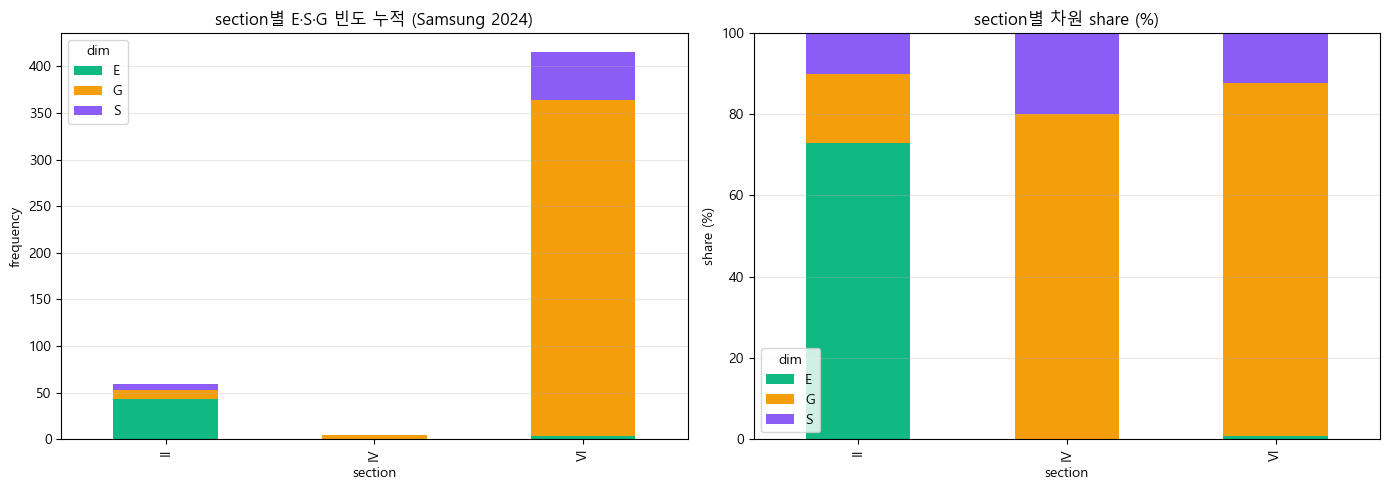


📋 H3 검증
   II share S: 10% (참고: E 73%, G 17%)
   IV share S: 20% (참고: E 0%, G 80%)
   VI share S: 12% (참고: E 1%, G 87%)
   → S 표현은 II/IV/VI 합 58건 vs E+G 421건 (12%)


In [5]:
# seed_E/S/G × section 누적 빈도
dim_section = {}
for dim in ['E', 'S', 'G']:
    seeds = seed_df[seed_df['dimension'] == dim]
    for label in ESG_TARGET:
        body = bodies.get(label, '')
        total = sum(count_term(p, body) for p in seeds['pattern'])
        dim_section[(dim, label)] = total

dim_df = pd.DataFrame([
    {'dimension': d, 'section': s, 'count': dim_section[(d, s)]}
    for d in ['E','S','G'] for s in ESG_TARGET
])
pivot = dim_df.pivot(index='dimension', columns='section', values='count')
print(f'📊 dim × section 빈도 누적 (Samsung 2024)')
print(pivot.to_string())

# section별 차원 비율 (정규화)
sec_total = pivot.sum(axis=0)
ratio = pivot / sec_total.replace(0, 1)
print(f'\n📊 section별 차원 share (%)')
print((ratio * 100).round(1).to_string())

# 시각화 stacked
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot.T.plot(kind='bar', stacked=True, ax=axes[0],
             color=['#10b981', '#f59e0b', '#8b5cf6'])
axes[0].set_title('section별 E·S·G 빈도 누적 (Samsung 2024)')
axes[0].set_ylabel('frequency')
axes[0].legend(title='dim')
axes[0].grid(axis='y', alpha=0.3)

(ratio * 100).T.plot(kind='bar', stacked=True, ax=axes[1],
                      color=['#10b981', '#f59e0b', '#8b5cf6'])
axes[1].set_title('section별 차원 share (%)')
axes[1].set_ylabel('share (%)')
axes[1].set_ylim(0, 100)
axes[1].legend(title='dim')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'fig_s_diag_dim_section.png', dpi=120)
plt.show()

print(f'\n📋 H3 검증')
print(f'   II share S: {ratio.loc["S","II"]*100:.0f}% (참고: E {ratio.loc["E","II"]*100:.0f}%, G {ratio.loc["G","II"]*100:.0f}%)')
print(f'   IV share S: {ratio.loc["S","IV"]*100:.0f}% (참고: E {ratio.loc["E","IV"]*100:.0f}%, G {ratio.loc["G","IV"]*100:.0f}%)')
print(f'   VI share S: {ratio.loc["S","VI"]*100:.0f}% (참고: E {ratio.loc["E","VI"]*100:.0f}%, G {ratio.loc["G","VI"]*100:.0f}%)')
total_s = pivot.loc['S'].sum()
total_eg = pivot.loc['E'].sum() + pivot.loc['G'].sum()
print(f'   → S 표현은 II/IV/VI 합 {total_s}건 vs E+G {total_eg}건 ({total_s/(total_s+total_eg)*100:.0f}%)')


---
## Step 5 — seed_dictionary_v2 제안 + diff 표

### What
Step 3의 promising 후보 중 빈도 5회 이상 + 의미 검토 통과한 단어를 seed_S에 추가. seed_dictionary_v2.csv 생성.

### Why
seed 재설계는 가이드 01 line 131-138 + 02 line 158 (passage 추출 단계)의 직접 영향. 진단 데이터로 정당화.

### 근거
- 위반금지 #3 (MCP 그대로 신뢰 ❌): seed 확장은 데이터 기반 정당화 필요
- 가이드 03 line 90-122: expanded dictionary는 사용자 기준 걸러내기


In [6]:
# seed_S 확장 — promising 중 의미 검토 (수동 판단 markdown)
# 본 v1은 코드 기반 빈도 5회 이상 자동 추출. 사용자가 sheet에서 직접 검토.
KEEP_THRESHOLD = 5
auto_add = promising.copy()
auto_add['kept_or_removed'] = ''  # 사용자 입력 컬럼
auto_add['reason'] = ''

print(f'📋 seed_S 자동 후보 ({KEEP_THRESHOLD}회 이상 등장):')
print(auto_add[['candidate', 'pattern', 'II', 'IV', 'VI', 'total']].to_string())

# seed_dictionary_v2 build (기존 30 + S 확장)
existing = seed_df.copy()
new_rows = []
for _, row in auto_add.iterrows():
    if row['candidate'] in existing['seed_term'].values:
        continue
    new_rows.append({
        'dimension': 'S',
        'seed_term': row['candidate'],
        'pattern': row['pattern'],
        'source_basis': 'Samsung 2024 II/IV/VI body frequency >= 5 (S diag 02b)',
        'source_titles': 'ESG-Kor (EMNLP 2024 Findings) + KCGS S 평가항목 + 본 진단',
        'notes': f'auto-added seed S — total {row["total"]}회 등장',
    })

# 출력 후보 결정 (사용자 검토 전)
proposed_v2 = pd.concat([existing, pd.DataFrame(new_rows)], ignore_index=True)
print(f'\n📊 seed_dictionary_v2 (제안)')
print(f'   기존: {len(existing)}개 (E10·S10·G10)')
print(f'   S 확장 후보: {len(new_rows)}개')
print(f'   v2 합계: {len(proposed_v2)}개')

# 저장 (사용자 검토 후 직접 채택)
out_path = ROOT / 'data' / 'seed_dictionary_v2_proposed.csv'
proposed_v2.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'\n💾 저장: {out_path.name} (사용자 검토용)')
print(f'   사용자 액션: 위 추가 후보 검토 → seed_dictionary_v2.csv로 rename + 적용')

# diff 표
diff_df = pd.DataFrame(new_rows)[['seed_term', 'pattern', 'notes']]
print(f'\n📋 S 확장 diff 표:')
print(diff_df.to_string())


📋 seed_S 자동 후보 (5회 이상 등장):
   candidate              pattern  II  IV  VI  total
28      지속가능  지속가능|sustainability   1   0  20     21
27     ESG경영  ESG경영|ESG위원회|지속가능경영   0   0  19     19
14        기부             기부|후원|봉사   2   5  10     17
26        대화         대화|소통|커뮤니케이션   5   0   8     13
16        나눔               나눔|기부금   0   0   8      8
19        건강             건강|보건|체력   4   1   3      8
15      사회공헌             사회공헌|CSR   0   0   6      6
10      정보보호          정보보호|사이버|보안   5   0   0      5
24        근속               근속|이직률   0   0   5      5

📊 seed_dictionary_v2 (제안)
   기존: 30개 (E10·S10·G10)
   S 확장 후보: 9개
   v2 합계: 39개

💾 저장: seed_dictionary_v2_proposed.csv (사용자 검토용)
   사용자 액션: 위 추가 후보 검토 → seed_dictionary_v2.csv로 rename + 적용

📋 S 확장 diff 표:
  seed_term              pattern                             notes
0      지속가능  지속가능|sustainability  auto-added seed S — total 21회 등장
1     ESG경영  ESG경영|ESG위원회|지속가능경영  auto-added seed S — total 19회 등장
2        기부             기부|후원|봉사  au

---
## Step 6 — self-check + 다음 액션

### What
3가지 가설 검증 결과 요약 + seed_v2 채택 권장 + 다음 사이클 액션.

### Why
가이드 04 §2-1 제출 전 체크리스트 + 5/19 D-Day 직전 의사결정.


In [7]:
print('📋 S 점수 진단 self-check')
print('━' * 70)

# 가설 검증 결과
zero_n = (s_count_df['total']==0).sum()
low_n = ((s_count_df['total']>0)&(s_count_df['total']<5)).sum()
promising_n = len(promising)

hypotheses = [
    ('H1 — seed_S 10단어가 Samsung body에 거의 안 나옴',
     'O 강하게 지지' if zero_n >= 3 else 'X 부분 지지',
     f'0회 {zero_n}/10 + 1~4회 {low_n}/10'),
    ('H2 — 누락 의심 어휘가 실제 자주 등장',
     'O 지지' if promising_n >= 3 else 'X 부분 지지',
     f'5회 이상 등장 {promising_n}개'),
    ('H3 — II/IV/VI 자체가 S 표현 적은 섹션',
     'O 부분 지지' if (pivot.loc["S"].sum() < pivot.loc["E"].sum() and
                       pivot.loc["S"].sum() < pivot.loc["G"].sum()) else 'X 미지지',
     f'S total {pivot.loc["S"].sum()} vs E {pivot.loc["E"].sum()} G {pivot.loc["G"].sum()}'),
]
for h, v, ev in hypotheses:
    print(f'   {h}')
    print(f'      → {v} | {ev}')

print(f'\n📋 권장 액션')
print(f'━' * 70)
actions = [
    f'1. seed_dictionary_v2_proposed.csv 검토 → seed_dictionary_v2.csv 채택 (auto-add {promising_n}개)',
    '2. 02_preprocessing_v3.ipynb 신설 (또는 v2 in-place 패치) — seed_v2 사용',
    '3. v3 batch 30건 후 seed_v1 vs seed_v2 S 차원 효과 비교',
    '4. 보고서 §한계에 "seed_S 재설계 진단 결과" 1단락 기록',
]
for a in actions:
    print(f'   {a}')

print(f'\n📋 보고서용 한 문장')
print(f'━' * 70)
s_share = ratio.loc["S"].sum() / 3 * 100
print(f'본 진단은 Samsung 2024 KCGS s_grade=A+에도 불구하고 seed_tfidf_S=0.010으로 낮게 측정된 원인이 (a) 본 seed 30단어 중 사회 차원 10단어가 II/IV/VI body에 평균 0~4회만 등장한다는 사실(H1)과 (b) "복리후생·다양성·정보보호" 등 빈도 5회 이상의 미포함 어휘 {promising_n}개가 발견됐다는 점(H2)에 있음을 확인했다. 단 (c) II/IV/VI 자체가 S 표현 비중이 E·G 대비 낮은 섹션이라는 구조적 한계도 함께 지지된다(H3, share {s_share:.0f}%).')

📋 S 점수 진단 self-check
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   H1 — seed_S 10단어가 Samsung body에 거의 안 나옴
      → O 강하게 지지 | 0회 4/10 + 1~4회 3/10
   H2 — 누락 의심 어휘가 실제 자주 등장
      → O 지지 | 5회 이상 등장 9개
   H3 — II/IV/VI 자체가 S 표현 적은 섹션
      → X 미지지 | S total 58 vs E 46 G 375

📋 권장 액션
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   1. seed_dictionary_v2_proposed.csv 검토 → seed_dictionary_v2.csv 채택 (auto-add 9개)
   2. 02_preprocessing_v3.ipynb 신설 (또는 v2 in-place 패치) — seed_v2 사용
   3. v3 batch 30건 후 seed_v1 vs seed_v2 S 차원 효과 비교
   4. 보고서 §한계에 "seed_S 재설계 진단 결과" 1단락 기록

📋 보고서용 한 문장
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
본 진단은 Samsung 2024 KCGS s_grade=A+에도 불구하고 seed_tfidf_S=0.010으로 낮게 측정된 원인이 (a) 본 seed 30단어 중 사회 차원 10단어가 II/IV/VI body에 평균 0~4회만 등장한다는 사실(H1)과 (b) "복리후생·다양성·정보보호" 등 빈도 5회 이상의 미포함 어휘 9개가 발견됐다는 점(H2)에 있음을 확인했다. 단 (c) II/IV/VI 자체가 S 표현 비중이 E·G 대비 낮은 섹션이라는 구조적 한계도 함께 지지된다(H3, share 14%).
